# Portfolio Construction & Allocation

The objective of this notebook is to move from individual asset analysis to portfolio-level analysis.

In the previous phase, each asset was analysed independently using risk and return metrics. In this phase, assets are combined into different portfolio allocations to study how weights, diversification and asset mix affect portfolio performance and risk.

The portfolios analysed are:

- Equal Weight Portfolio
- Equity Heavy Portfolio
- Defensive Portfolio
- Growth Tech Portfolio
- Balanced Portfolio

In [3]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src/quant_risk_lab")

from quant_risk_lab.portfolio import (
    DEFAULT_PORTFOLIOS,
    compute_portfolio_returns,
    compute_multiple_portfolio_returns,
    compute_portfolio_cumulative_returns,
    compute_portfolio_summary,
)

from quant_risk_lab.risk_metrics import (
    load_returns,
    compute_drawdowns,
)

## 1. Load Asset Returns

We start by loading the daily simple returns generated by the Market Data Pipeline.

In [4]:
returns = load_returns()

returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,-0.028172,0.015077,-0.031045,-0.009196,-0.016890,-0.018060,0.015709,-0.027362
2015-01-06,0.000094,0.011399,-0.025929,-0.014678,-0.030318,-0.009419,0.018017,-0.005317
2015-01-07,0.014022,-0.005891,0.001526,0.012706,-0.002605,0.012461,-0.001975,0.010133
2015-01-08,0.038422,-0.004209,0.022346,0.029418,0.037617,0.017745,-0.013243,0.016645
2015-01-09,0.001072,0.011385,-0.017387,-0.008405,0.004028,-0.008014,0.010952,-0.001410


In [5]:
returns.shape

(2890, 8)

## 2. Portfolio Definitions

The following portfolios are manually defined using different allocation weights.

Each portfolio represents a different investment profile:

- Equal Weight: simple benchmark allocation.
- Equity Heavy: high exposure to equities.
- Defensive: higher allocation to bonds and gold.
- Growth Tech: concentrated exposure to technology and growth stocks.
- Balanced: diversified allocation across equities, bonds and gold.

In [6]:
portfolio_weights = pd.DataFrame(DEFAULT_PORTFOLIOS).T

portfolio_weights

,AAPL,MSFT,NVDA,JPM,XOM,SPY,TLT,GLD
Equal Weight,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
Equity Heavy,0.150,0.150,0.150,0.100,0.100,0.250,0.050,0.050
Defensive,0.050,0.050,0.000,0.000,0.000,0.300,0.350,0.250
Growth Tech,0.250,0.250,0.250,0.000,0.000,0.150,0.050,0.050
Balanced,0.100,0.100,0.050,0.050,0.050,0.350,0.200,0.100


In [7]:
portfolio_weights.sum(axis=1)

Equal Weight    1.0
Equity Heavy    1.0
Defensive       1.0
Growth Tech     1.0
Balanced        1.0
dtype: float64

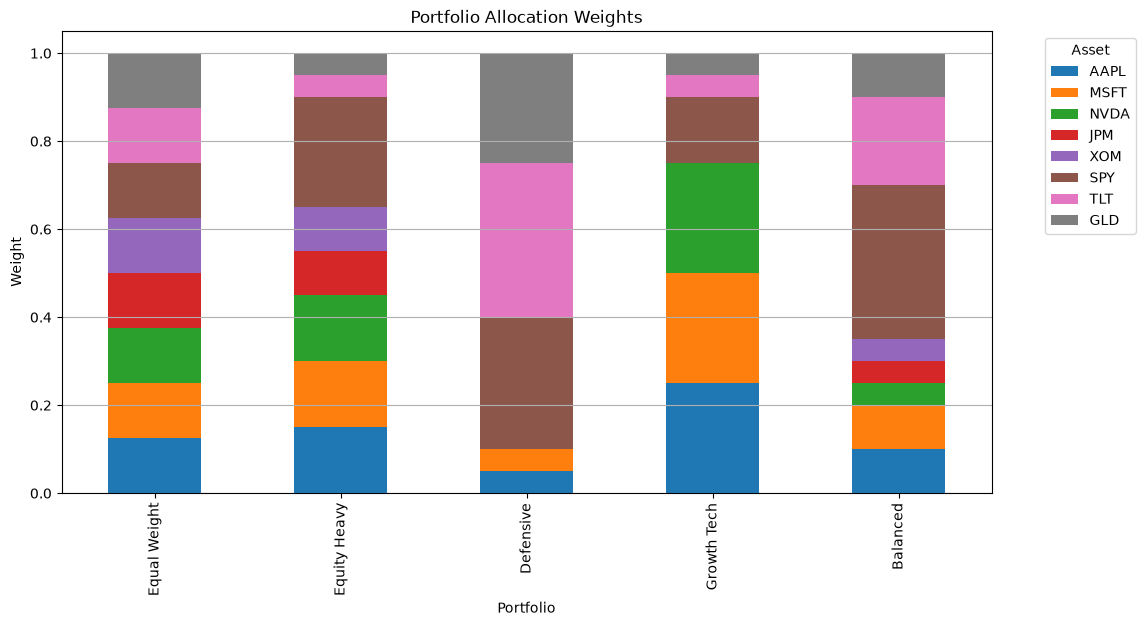

In [8]:
portfolio_weights.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Portfolio Allocation Weights")
plt.ylabel("Weight")
plt.xlabel("Portfolio")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.show()

## 3. Portfolio Returns

A portfolio return is computed as the weighted sum of the returns of its assets.

For example, if a portfolio has 50% in AAPL and 50% in GLD, its daily return is:

Portfolio Return = 0.5 × AAPL Return + 0.5 × GLD Return

In [9]:
portfolio_returns = compute_multiple_portfolio_returns(returns)

portfolio_returns.head()

,Equal Weight,Equity Heavy,Defensive,Growth Tech,Balanced
Date,,,,,
2015-01-05,-0.012492,-0.016955,0.001981,-0.014734,-0.009173
2015-01-06,-0.007019,-0.010744,0.005601,-0.011168,-0.003090
2015-01-07,0.005047,0.007506,0.002911,0.007507,0.006503
2015-01-08,0.018093,0.023281,0.003028,0.028154,0.013756
2015-01-09,-0.000972,-0.003262,0.003909,-0.000911,-0.000948


In [10]:
portfolio_returns.shape

(2890, 5)

In [11]:
output_path = Path("../data/processed/portfolio_returns.csv")
portfolio_returns.to_csv(output_path)

output_path

PosixPath('../data/processed/portfolio_returns.csv')

## 4. Portfolio Cumulative Returns

Cumulative returns show how one monetary unit invested in each portfolio would have evolved over time.

In [12]:
portfolio_cumulative_returns = compute_portfolio_cumulative_returns(portfolio_returns)

portfolio_cumulative_returns.head()

,Equal Weight,Equity Heavy,Defensive,Growth Tech,Balanced
Date,,,,,
2015-01-05,0.987508,0.983045,1.001981,0.985266,0.990827
2015-01-06,0.980577,0.972483,1.007593,0.974263,0.987766
2015-01-07,0.985526,0.979783,1.010526,0.981576,0.994189
2015-01-08,1.003357,1.002594,1.013586,1.009211,1.007865
2015-01-09,1.002381,0.999324,1.017548,1.008291,1.006910


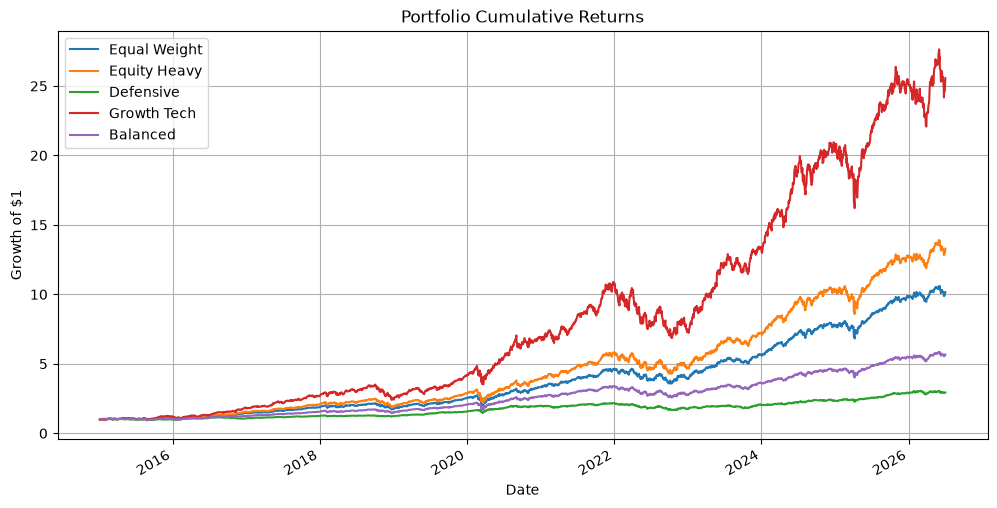

In [13]:
portfolio_cumulative_returns.plot(figsize=(12, 6))
plt.title("Portfolio Cumulative Returns")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 5. Portfolio Risk and Return Summary

The following table computes risk and return metrics for each portfolio.

This allows us to compare portfolio performance not only by return, but also by volatility, drawdowns and downside risk.

In [14]:
portfolio_summary = compute_portfolio_summary(portfolio_returns)

portfolio_summary

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
Equal Weight,0.216006,0.224109,0.165555,-0.265244,1.183934,1.536996,0.015268,0.024128
Equity Heavy,0.245402,0.253026,0.198596,-0.309526,1.134980,1.462306,0.018727,0.029295
Defensive,0.099025,0.098504,0.100592,-0.240187,0.785596,1.071108,0.009687,0.014586
Growth Tech,0.312547,0.326621,0.244028,-0.370462,1.198825,1.629036,0.023725,0.035342
Balanced,0.161207,0.163425,0.139937,-0.241182,1.009072,1.295020,0.013187,0.020668


In [15]:
portfolio_summary_percent = portfolio_summary.copy()

percentage_columns = [
    "Annualized Return",
    "CAGR",
    "Annualized Volatility",
    "Maximum Drawdown",
    "Historical VaR 95%",
    "Historical CVaR 95%",
]

portfolio_summary_percent[percentage_columns] = (
    portfolio_summary_percent[percentage_columns] * 100
)

portfolio_summary_percent

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
Equal Weight,21.600586,22.410922,16.555467,-26.524385,1.183934,1.536996,1.526781,2.412834
Equity Heavy,24.540195,25.302647,19.859556,-30.952603,1.134980,1.462306,1.872708,2.929515
Defensive,9.902451,9.850382,10.059186,-24.018747,0.785596,1.071108,0.968691,1.458553
Growth Tech,31.254658,32.662072,24.402767,-37.046243,1.198825,1.629036,2.372547,3.534170
Balanced,16.120659,16.342464,13.993708,-24.118234,1.009072,1.295020,1.318703,2.066791


In [16]:
output_path = Path("../data/processed/portfolio_summary.csv")
portfolio_summary.to_csv(output_path)

output_path

PosixPath('../data/processed/portfolio_summary.csv')

## 6. CAGR Comparison

CAGR measures the annual compounded growth rate of each portfolio over the analysed period.

In [17]:
portfolio_summary["CAGR"].sort_values(ascending=False)

Growth Tech     0.326621
Equity Heavy    0.253026
Equal Weight    0.224109
Balanced        0.163425
Defensive       0.098504
Name: CAGR, dtype: float64

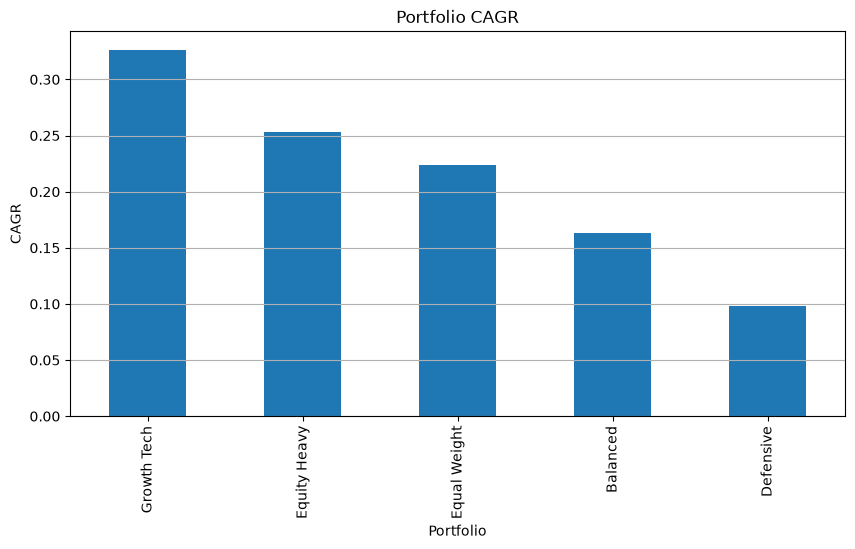

In [18]:
portfolio_summary["CAGR"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio CAGR")
plt.ylabel("CAGR")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 7. Volatility Comparison

Annualized volatility measures the dispersion of portfolio returns over time.

In [19]:
portfolio_summary["Annualized Volatility"].sort_values(ascending=False)

Growth Tech     0.244028
Equity Heavy    0.198596
Equal Weight    0.165555
Balanced        0.139937
Defensive       0.100592
Name: Annualized Volatility, dtype: float64

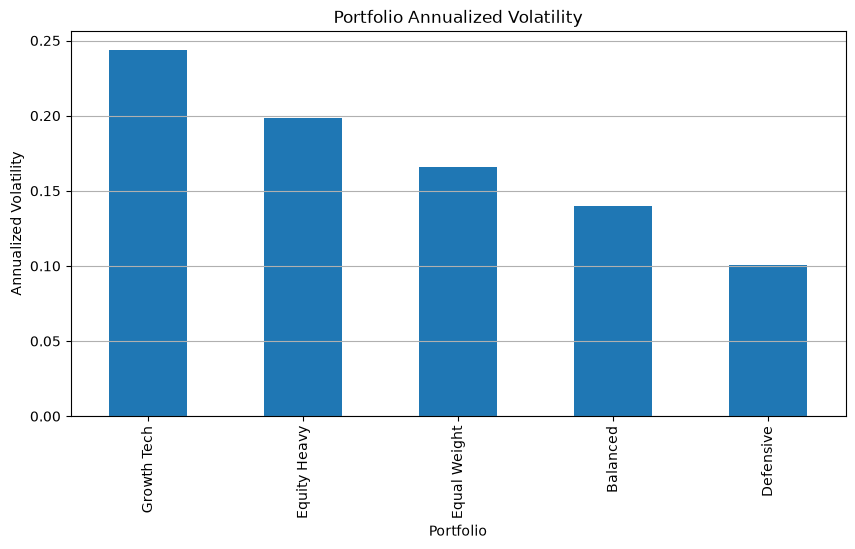

In [20]:
portfolio_summary["Annualized Volatility"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio Annualized Volatility")
plt.ylabel("Annualized Volatility")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 8. Maximum Drawdown Comparison

Maximum Drawdown measures the worst historical loss from a previous portfolio peak.

In [21]:
portfolio_summary["Maximum Drawdown"].sort_values()

Growth Tech    -0.370462
Equity Heavy   -0.309526
Equal Weight   -0.265244
Balanced       -0.241182
Defensive      -0.240187
Name: Maximum Drawdown, dtype: float64

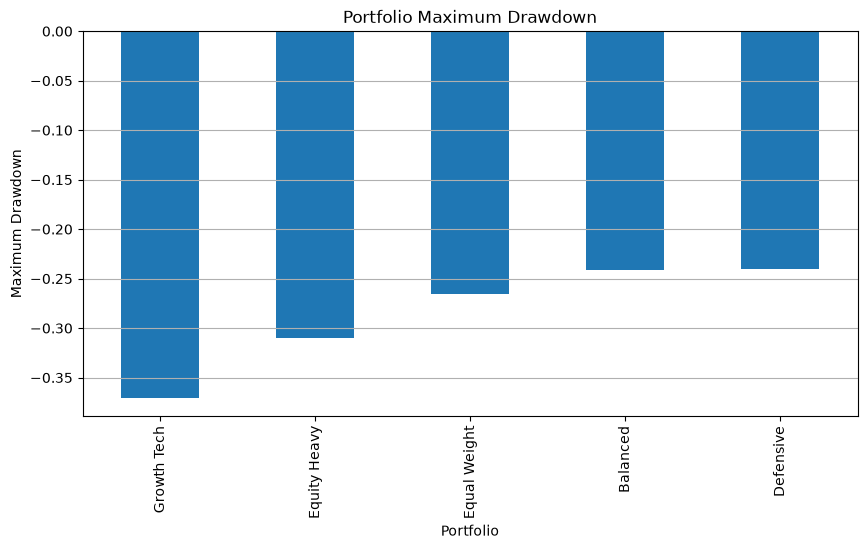

In [22]:
portfolio_summary["Maximum Drawdown"].sort_values().plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio Maximum Drawdown")
plt.ylabel("Maximum Drawdown")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 9. Portfolio Drawdowns Over Time

This chart shows the historical drawdown path of each portfolio.

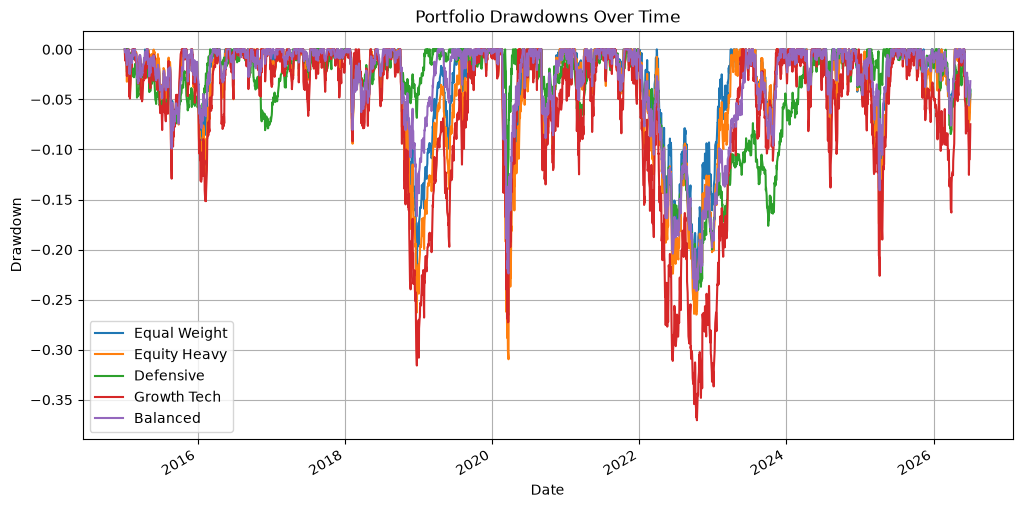

In [23]:
portfolio_drawdowns = compute_drawdowns(portfolio_returns)

portfolio_drawdowns.plot(figsize=(12, 6))
plt.title("Portfolio Drawdowns Over Time")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 10. Sharpe Ratio Comparison

Sharpe Ratio measures excess return per unit of total volatility.

In [24]:
portfolio_summary["Sharpe Ratio"].sort_values(ascending=False)

Growth Tech     1.198825
Equal Weight    1.183934
Equity Heavy    1.134980
Balanced        1.009072
Defensive       0.785596
Name: Sharpe Ratio, dtype: float64

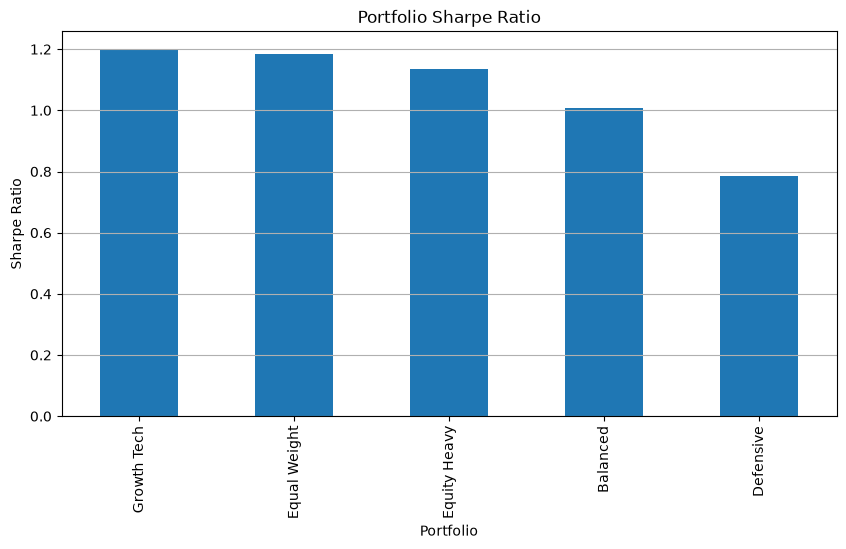

In [25]:
portfolio_summary["Sharpe Ratio"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 11. Sortino Ratio Comparison

Sortino Ratio measures excess return per unit of downside volatility.

In [26]:
portfolio_summary["Sortino Ratio"].sort_values(ascending=False)

Growth Tech     1.629036
Equal Weight    1.536996
Equity Heavy    1.462306
Balanced        1.295020
Defensive       1.071108
Name: Sortino Ratio, dtype: float64

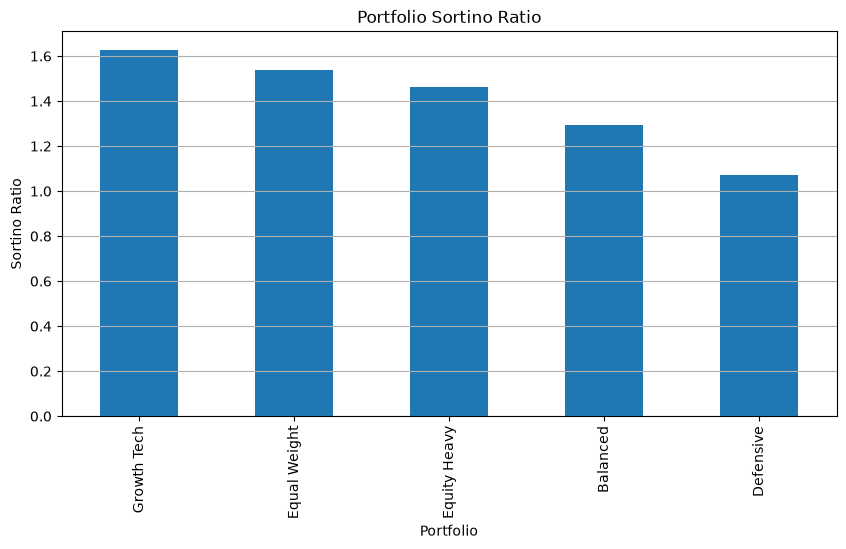

In [27]:
portfolio_summary["Sortino Ratio"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio Sortino Ratio")
plt.ylabel("Sortino Ratio")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 12. Historical VaR 95% Comparison

Historical VaR 95% estimates the daily loss threshold that was not exceeded in 95% of historical observations.

In [28]:
portfolio_summary["Historical VaR 95%"].sort_values(ascending=False)

Growth Tech     0.023725
Equity Heavy    0.018727
Equal Weight    0.015268
Balanced        0.013187
Defensive       0.009687
Name: Historical VaR 95%, dtype: float64

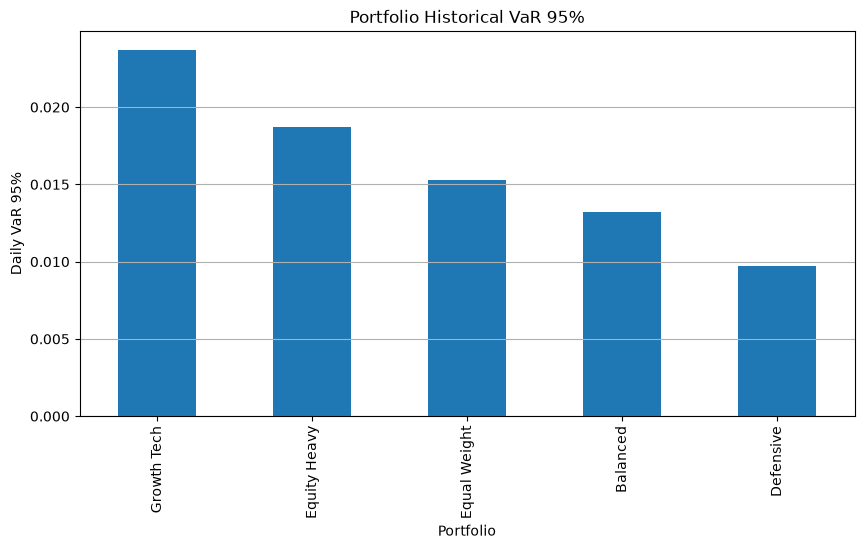

In [29]:
portfolio_summary["Historical VaR 95%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio Historical VaR 95%")
plt.ylabel("Daily VaR 95%")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 13. Historical CVaR 95% Comparison

Historical CVaR 95% measures the average daily loss inside the worst 5% of historical observations.

In [30]:
portfolio_summary["Historical CVaR 95%"].sort_values(ascending=False)

Growth Tech     0.035342
Equity Heavy    0.029295
Equal Weight    0.024128
Balanced        0.020668
Defensive       0.014586
Name: Historical CVaR 95%, dtype: float64

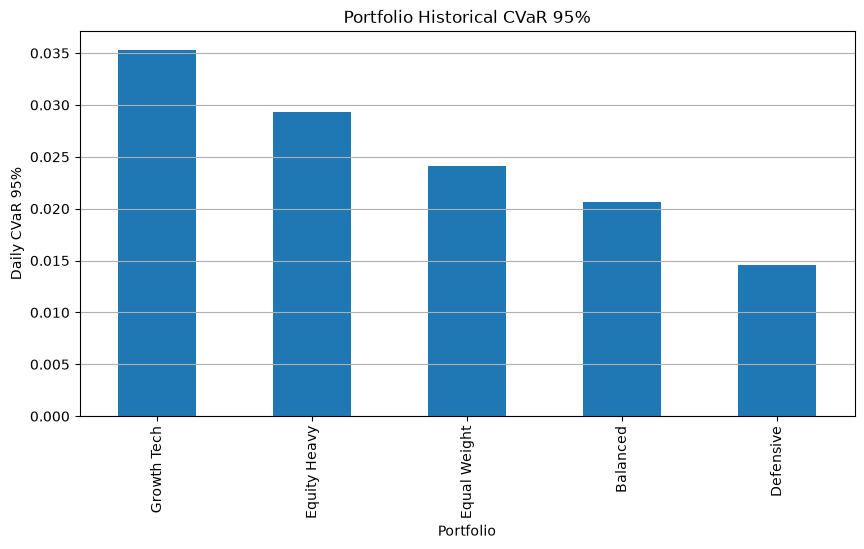

In [31]:
portfolio_summary["Historical CVaR 95%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Portfolio Historical CVaR 95%")
plt.ylabel("Daily CVaR 95%")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 14. Final Portfolio Ranking

The following tables rank portfolios by return, risk and risk-adjusted performance.

In [32]:
portfolio_summary.sort_values("CAGR", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
Growth Tech,0.312547,0.326621,0.244028,-0.370462,1.198825,1.629036,0.023725,0.035342
Equity Heavy,0.245402,0.253026,0.198596,-0.309526,1.134980,1.462306,0.018727,0.029295
Equal Weight,0.216006,0.224109,0.165555,-0.265244,1.183934,1.536996,0.015268,0.024128
Balanced,0.161207,0.163425,0.139937,-0.241182,1.009072,1.295020,0.013187,0.020668
Defensive,0.099025,0.098504,0.100592,-0.240187,0.785596,1.071108,0.009687,0.014586


In [33]:
portfolio_summary.sort_values("Annualized Volatility")

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
Defensive,0.099025,0.098504,0.100592,-0.240187,0.785596,1.071108,0.009687,0.014586
Balanced,0.161207,0.163425,0.139937,-0.241182,1.009072,1.295020,0.013187,0.020668
Equal Weight,0.216006,0.224109,0.165555,-0.265244,1.183934,1.536996,0.015268,0.024128
Equity Heavy,0.245402,0.253026,0.198596,-0.309526,1.134980,1.462306,0.018727,0.029295
Growth Tech,0.312547,0.326621,0.244028,-0.370462,1.198825,1.629036,0.023725,0.035342


In [34]:
portfolio_summary.sort_values("Sharpe Ratio", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
Growth Tech,0.312547,0.326621,0.244028,-0.370462,1.198825,1.629036,0.023725,0.035342
Equal Weight,0.216006,0.224109,0.165555,-0.265244,1.183934,1.536996,0.015268,0.024128
Equity Heavy,0.245402,0.253026,0.198596,-0.309526,1.134980,1.462306,0.018727,0.029295
Balanced,0.161207,0.163425,0.139937,-0.241182,1.009072,1.295020,0.013187,0.020668
Defensive,0.099025,0.098504,0.100592,-0.240187,0.785596,1.071108,0.009687,0.014586


In [35]:
portfolio_summary.sort_values("Maximum Drawdown", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
Defensive,0.099025,0.098504,0.100592,-0.240187,0.785596,1.071108,0.009687,0.014586
Balanced,0.161207,0.163425,0.139937,-0.241182,1.009072,1.295020,0.013187,0.020668
Equal Weight,0.216006,0.224109,0.165555,-0.265244,1.183934,1.536996,0.015268,0.024128
Equity Heavy,0.245402,0.253026,0.198596,-0.309526,1.134980,1.462306,0.018727,0.029295
Growth Tech,0.312547,0.326621,0.244028,-0.370462,1.198825,1.629036,0.023725,0.035342


## Key Insights

This phase moves the project from individual asset analysis to portfolio-level decision analysis.

The results show how different allocation choices lead to different risk and return profiles. Portfolios with higher exposure to technology and growth assets may achieve higher historical returns, but they also tend to experience higher volatility, deeper drawdowns and larger downside risk.

More defensive or diversified portfolios may show lower returns, but they can reduce volatility and limit downside losses during adverse periods.

This highlights a central principle of quantitative decision-making: the best decision is not necessarily the one with the highest return, but the one that offers the best balance between return, risk, constraints and objectives.

The next phase will extend this analysis by computing portfolio-level risk analytics in more detail and preparing the portfolios for scenario analysis and stress testing.